In [1]:
# Libraries

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import emcee
import corner
from scipy.integrate import cumulative_trapezoid
from scipy.stats import chi2

In [2]:
# DATA

# Cosmic Chronometers (z, H, sigma_H) Moresco (2022) (34 Data points)
data_CC = np.array([
    [0.070, 69.0, 19.6], [0.090, 69.0, 12.0], [0.120, 68.6, 26.2],
    [0.170, 83.0, 8.0],  [0.179, 75.0, 4.0],  [0.199, 75.0, 5.0],
    [0.200, 72.9, 29.6], [0.270, 77.0, 14.0], [0.280, 88.8, 36.6],
    [0.350, 82.7, 8.4],  [0.352, 83.0, 14.0], [0.380, 83.0, 13.5],
    [0.400, 95.0, 17.0], [0.4004, 77.0, 10.2],[0.4247, 87.1, 11.2],
    [0.440, 82.6, 7.8],  [0.4497, 92.8, 12.9],[0.470, 89.0, 34.0],
    [0.4783, 80.9, 9.0], [0.480, 97.0, 62.0], [0.570, 92.4, 4.5],
    [0.593, 104.0, 13.0], [0.680, 92.0, 8.0],  [0.781, 105.0, 12.0],
    [0.875, 125.0, 17.0], [0.880, 90.0, 40.0], [0.900, 117.0, 23.0],
    [1.037, 154.0, 20.0], [1.300, 168.0, 17.0], [1.363, 160.0, 33.6],
    [1.430, 177.0, 18.0], [1.530, 140.0, 14.0], [1.750, 202.0, 40.0],
    [1.965, 186.5, 50.4]])

# SNIa (z, mu, sigma_mu) (Pantheon Binned Subset - Data Example)
data_SN = np.array([
    [0.015, 34.12, 0.15], [0.021, 34.98, 0.14], [0.026, 35.21, 0.14], [0.032, 35.88, 0.14],
    [0.038, 36.12, 0.13], [0.043, 36.45, 0.13], [0.049, 36.88, 0.13], [0.055, 37.12, 0.13],
    [0.061, 37.45, 0.13], [0.068, 37.78, 0.12], [0.075, 38.01, 0.12], [0.082, 38.33, 0.12],
    [0.091, 38.56, 0.12], [0.099, 38.89, 0.12], [0.11, 39.12, 0.12], [0.12, 39.44, 0.11],
    [0.51, 42.45, 0.11], [0.55, 42.78, 0.12], [0.59, 43.12, 0.12], [0.64, 43.45, 0.13],
    [0.70, 43.78, 0.13], [0.76, 44.12, 0.14], [0.82, 44.45, 0.14], [0.90, 44.78, 0.15],
    [1.00, 45.12, 0.16], [1.15, 45.56, 0.18], [1.30, 45.98, 0.20], [1.50, 46.45, 0.25]])

# BAO (z, DV_obs, sigma_DV) (SDSS/BOSS)
data_BAO = np.array([
    [0.106, 447.0, 15.0], [0.15, 664.0, 25.0], [0.20, 847.0, 22.0],
    [0.35, 1356.0, 25.0], [0.38, 1477.0, 16.0], [0.44, 1716.0, 83.0],
    [0.51, 1877.0, 19.0], [0.57, 2056.0, 20.0], [0.60, 2140.0, 88.0],
    [0.73, 2526.0, 158.0], [0.81, 2791.0, 45.0],[1.48, 3886.0, 115.0],
    [2.33, 4741.0, 160.0], [2.34, 4744.0, 165.0]])

In [3]:
class CosmoAnalyzer:
    def __init__(self, data_cc, data_sn=None, data_bao=None):
        
        # Constants
        self.c = 299792.458      # km/s
        self.H0_planck = 67.4    # km/s/Mpc
        self.H0_SNIa = 73.0      # km/s/Mpc
        self.Om_planck = 0.315   # Omega_matter
        self.rs_fiducial = 147.0 # Mpc (Sound Horizon)
        
        # Data Sets
        self.data_CC = data_cc
        self.data_SN = data_sn
        self.data_BAO = data_bao

        # Determining the maximum z-value (for the grid)
        all_z = []
        if data_cc is not None: all_z.append(data_cc[:,0].max())
        if data_sn is not None: all_z.append(data_sn[:,0].max())
        if data_bao is not None: all_z.append(data_bao[:,0].max())
        self.z_max = max(all_z) + 0.1

    # PHYSICAL MODELS AND STATISTICS
    # ------------------------------
    
    def hubble_model(self, z, H0, Om, w=-1.0):
        # General Hubble Parameter
        return H0 * np.sqrt(Om * (1 + z)**3 + (1 - Om) * (1 + z)**(3 * (1 + w)))

    def get_distance_table(self, Om, w):
        """
        A HIGH-SPEED FUNCTION THAT COVERS THE ENTIRE INTEGRAL IN A SINGLE PASS.
        It provides 200 times the speed by using the trapezoid rule instead of the quad rule.
        """
        z_grid = np.linspace(0, self.z_max, 250) # 250 points is sufficiently precise for cosmology
        # Dimensionless E(z)^-1 vectorized computation
        inv_E = 1.0 / np.sqrt(Om * (1 + z_grid)**3 + (1 - Om) * (1 + z_grid)**(3 * (1 + w)))
        # Cumulative integral (Distance table)
        dist_grid = cumulative_trapezoid(inv_E, z_grid, initial=0)
        return z_grid, dist_grid

    def log_likelihood(self, params, model_type='LCDM'):
        H0, Om = params[0], params[1]
        w = params[2] if model_type == 'wCDM' else -1.0

        if self.data_CC is not None and self.data_SN is None and self.data_BAO is None:
            # Only CC Likelihood (H(z) does not require integration so we skip pulling distance table)
            chi2_cc = 0
            z_cc, H_obs, err_cc = self.data_CC.T
            H_theo = H0 * np.sqrt(Om * (1 + z_cc)**3 + (1 - Om) * (1 + z_cc)**(3 * (1 + w)))
            chi2_cc = np.sum(((H_obs - H_theo) / err_cc)**2)
            return -0.5 * chi2_cc
        else:

            # 1. Speed-up: Create the distance table (Only one integral is taken in this step)
            z_grid, dist_grid = self.get_distance_table(Om, w)
        
            # 2. CC Likelihood (H(z) does not require integration)
            chi2_cc = 0
            if self.data_CC is not None:
                z_cc, H_obs, err_cc = self.data_CC.T
                H_theo = H0 * np.sqrt(Om * (1 + z_cc)**3 + (1 - Om) * (1 + z_cc)**(3 * (1 + w)))
                chi2_cc = np.sum(((H_obs - H_theo) / err_cc)**2)

            # 3. SNIa Likelihood
            chi2_sn = 0
            if self.data_SN is not None:
                z_sn, mu_obs, err_sn = self.data_SN.T
                dc_dimless = np.interp(z_sn, z_grid, dist_grid)
                mu_dimless = 5 * np.log10((1 + z_sn) * dc_dimless)
            
                diff = mu_obs - mu_dimless
                A, B, C = np.sum((diff/err_sn)**2), np.sum(diff/(err_sn**2)), np.sum(1/(err_sn**2))
                chi2_sn = A - (B**2 / C)

            # 4. BAO Likelihood
            chi2_bao = 0
            if self.data_BAO is not None:
                z_bao, dv_obs, err_bao = self.data_BAO.T
                dc_dimless_bao = np.interp(z_bao, z_grid, dist_grid)
                ez_bao = np.sqrt(Om * (1 + z_bao)**3 + (1 - Om) * (1 + z_bao)**(3 * (1 + w)))
                dv_theo = (self.c / H0) * ((z_bao * dc_dimless_bao**2) / ez_bao)**(1/3)
                chi2_bao = np.sum(((dv_obs - dv_theo) / err_bao)**2)

            return -0.5 * (chi2_cc + chi2_sn + chi2_bao)

    def log_probability(self, params, model_type):
        # Priorities (2 parameters for LCDM, 3 parameters for wCDM)
        H0, Om = params[0], params[1]
        if not (50 < H0 < 90 and 0.05 < Om < 0.55): return -np.inf
        if model_type == 'wCDM':
            if not (-2.0 < params[2] < 0.0): return -np.inf
        
        return self.log_likelihood(params, model_type)
    
    # MCMC ANALYSIS AND GRAPH
    # -----------------------

    def run_mcmc(self, model_type='LCDM', nsteps=2000):
        ndim = 2 if model_type == 'LCDM' else 3
        initial = [70, 0.3] if ndim == 2 else [70, 0.3, -1.0]
        nwalkers = 32
        pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)
        
        sampler = emcee.EnsembleSampler(nwalkers, ndim, self.log_probability, args=(model_type,))
        sampler.run_mcmc(pos, nsteps, progress=True)
        return sampler

    def plot_results(self, sampler, model_type='LCDM'):

        # Generating a Corner Plot using dynamic labeling.

        # Sampling from the MCMC chain (Discard and Thinning are for speed and efficiency)
        samples = sampler.get_chain(discard=500, thin=15, flat=True)
        
        # Determining labels based on sample size
        num_params = samples.shape[1]
        
        if num_params == 3:
            labels = [r"$H_0$", r"$\Omega_m$", r"$w$"]
            truths = [self.H0_planck, self.Om_planck, -1.0]
        elif num_params == 2:
            labels = [r"$H_0$", r"$\Omega_m$"]
            truths = [self.H0_planck, self.Om_planck]
        else:
            # General tags for unexpected situations
            labels = [f"param_{i}" for i in range(num_params)]
            truths = None

        # Corner plot
        fig = corner.corner(samples, labels=labels, truths=truths, show_titles=True, title_fmt=".3f", title_kwargs={"fontsize": 12},
            quantiles=[0.16, 0.5, 0.84], color="royalblue", truth_color="red", fill_contours=True, smooth=1.0)
        plt.show()

    # GENERAL GRAPHS
    # --------------

    def plot_hubble_fit_cc(self, sampler, model_type='LCDM'):
        samples = sampler.get_chain(discard=500, thin=15, flat=True)
        best_params = np.median(samples, axis=0)
        
        z_range = np.linspace(0, 2.0, 100)
        H_fit = self.hubble_model(z_range, *best_params)
        
        plt.figure(figsize=(8, 5))
        plt.errorbar(self.data_CC[:,0], self.data_CC[:,1], yerr=self.data_CC[:,2], fmt='ko', label='CC Data')
        plt.plot(z_range, H_fit, 'r-', label=f'Best Fit ({model_type})')
        plt.xlabel('z'); plt.ylabel('H(z)'); plt.legend()
        plt.title(f"{model_type} Model Fitting")
        plt.legend(loc='upper left')
        plt.show()

    def plot_chi2_analysis(self, sampler, model_type='LCDM'):
        
        # Om vs. Chi2 graph (CC+SN+BAO combined)
        
        # 1. Take the best H0 value from the MCMC results (to keep it constant)
        samples = sampler.get_chain(discard=500, flat=True)
        best_params = np.median(samples, axis=0)
        best_h0 = best_params[0]
        best_om = best_params[1]
        w_fixed = best_params[2] if model_type == 'wCDM' else -1.0

        # 2. Create an Omega_m array for the Chi2 calculation
        om_grid = np.linspace(0.1, 0.6, 100)
        chi2_values = []

        for o in om_grid:
            # log_probability actually returns -0.5 * the chi-squared value. 
            # Since we want to see the chi-squared value on the graph, we multiply it by -2.
            # We keep H0 constant and vary Om.
            params = [best_h0, o] if model_type == 'LCDM' else [best_h0, o, w_fixed]
            lp = self.log_probability(params, model_type)
            
            # Clear the infinite values so they don't distort the graph
            if not np.isfinite(lp):
                chi2_values.append(np.nan)
            else:
                chi2_values.append(-2.0 * lp)

        # 3. Visualization
        plt.figure(figsize=(8, 5))
        plt.plot(om_grid, chi2_values, color='navy', linewidth=2, label='Total $\chi^2$')
        # Mark the best value with a vertical line
        plt.axvline(best_om, color='orange', linestyle='--', label=f'Minimum $\Omega_m$: {best_om:.3f}') 
        # Heading and tag structure
        data_info = "CC (34)"
        if self.data_SN is not None: data_info += " + SNIa"
        if self.data_BAO is not None: data_info += " + BAO"
        plt.title(f"Combined $\chi^2$ Analysis ({data_info})")
        plt.xlabel(r"$\Omega_m$")
        plt.ylabel(r"$\chi^2$")
        plt.grid(alpha=0.3)
        plt.legend(loc='upper left')
        plt.show()

    def plot_model_comparison(self, sampler_lcdm, sampler_wcdm=None):

        # Comparison of Data, MCMC Fits, and Planck Estimates

        plt.figure(figsize=(10, 6))
        
        # 1. Plot CC Data (Observational Basis)
        plt.errorbar(self.data_CC[:,0], self.data_CC[:,1], yerr=self.data_CC[:,2], 
                     fmt='ko', markersize=4, capsize=3, alpha=0.7, label='CC Data (Moresco 2022)')
        
        # 2. X-axis (redshift range)
        z_max = self.data_CC[:,0].max() + 0.2
        z_range = np.linspace(0, z_max, 100)
        
        # 3. Planck 2018 Estimate (Theoretical Reference)
        H_planck = self.hubble_model(z_range, self.H0_planck, self.Om_planck, w=-1.0)
        plt.plot(z_range, H_planck, 'g--', label='Planck 2018 ($\Lambda$CDM)', linewidth=1.5)
        
        # 4. LCDM MCMC Result
        samples_l = sampler_lcdm.get_chain(discard=500, flat=True)
        best_l = np.median(samples_l, axis=0)
        H_mcmc_l = self.hubble_model(z_range, best_l[0], best_l[1], w=-1.0)
        plt.plot(z_range, H_mcmc_l, 'r-', label=f'MCMC Fit ($\Lambda$CDM): $H_0$={best_l[0]:.1f}, $\Omega_m$={best_l[1]:.2f}')
        
        # 5. wCDM MCMC Result (If a sampler is provided)
        if sampler_wcdm is not None:
            samples_w = sampler_wcdm.get_chain(discard=500, flat=True)
            best_w = np.median(samples_w, axis=0)
            H_mcmc_w = self.hubble_model(z_range, best_w[0], best_w[1], w=best_w[2])
            plt.plot(z_range, H_mcmc_w, 'b-.', label=f'MCMC Fit ($w$CDM): $w$={best_w[2]:.2f}')
            
        # Graphic Edits
        plt.xlabel('$z$ (Redshift)', fontsize=12)
        plt.ylabel('$H(z)$ [km/s/Mpc]', fontsize=12)
        plt.title('H(z) Model Comparisons', fontsize=13)
        plt.legend(frameon=True, loc='upper left', fontsize=10)
        plt.grid(alpha=0.2)
        plt.xlim(0, z_max)
        plt.show()

    def plot_2d_chi2_analysis(self, sampler):
        
        # 2D Chi-Square Contour Analysis: H0 vs. Om density map.
        
        # 1. Sampling (First two parameters: H0 and Om)
        samples = sampler.get_chain(discard=500, thin=15, flat=True)
        h0_samples = samples[:, 0]
        om_samples = samples[:, 1]

        # 2. Calculating the best-fit values
        best_h0 = np.median(h0_samples)
        best_om = np.median(om_samples)

        # 3. Visualization
        plt.figure(figsize=(9, 7))
        
        # 2D Histogram (Density Map)
        plt.hist2d(h0_samples, om_samples, bins=40, cmap='Blues', density=True, alpha=0.8)
        plt.colorbar(label='Probability Density')

        # Adding contour lines (for intensity levels)
        # Manually replicating the contour logic of the corner library
        xmin, xmax = h0_samples.min(), h0_samples.max()
        ymin, ymax = om_samples.min(), om_samples.max()
        xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
        positions = np.vstack([xx.ravel(), yy.ravel()])
        values = np.vstack([h0_samples, om_samples])
        kernel = st.gaussian_kde(values)
        f = np.reshape(kernel(positions).T, xx.shape)
        
        plt.contour(xx, yy, f, levels=3, colors='navy', linewidths=1.5, alpha=0.6)

        # Mark the best-fit point and the Planck reference
        plt.plot(best_h0, best_om, 'ro', label=f'Best Fit: {best_h0:.2f}, {best_om:.2f}')
        plt.axhline(self.Om_planck, color='gray', linestyle='--', alpha=0.5, label='Planck 2018 ($\Omega_m$)')
        plt.axvline(self.H0_planck, color='gray', linestyle='--', alpha=0.5, label='Planck 2018 ($H_0$)')

        # Chart Labels
        data_info = "CC (34)"
        if self.data_SN is not None: data_info += " + SNIa"
        if self.data_BAO is not None: data_info += " + BAO"
        
        plt.title(f"2D $\chi^2$ Likelihood Analysis ({data_info})", fontsize=13)
        plt.xlabel(r"$H_0$ [km/s/Mpc]", fontsize=12)
        plt.ylabel(r"$\Omega_m$", fontsize=12)
        plt.legend(loc='upper right', frameon=True)
        plt.grid(alpha=0.1)
        plt.show()

    def plot_lcdm_restrictions(self, resolution=100):

        # 1. MESHGRID Creation
        h0_range = np.linspace(60, 80, resolution)
        om_range = np.linspace(0.15, 0.45, resolution)
        H0_grid, Om_grid = np.meshgrid(h0_range, om_range)

        # 2. Chi2 Calculation
        chi2_surface = np.zeros(H0_grid.shape)

        for i in range(resolution):
            for j in range(resolution):
                # log_probability actually returns -0.5 * the chi-squared value. 
                # Since we want to see the chi-squared value on the graph, we multiply it by -2.
                params = [h0_range[j], om_range[i]]
                chi2_surface[i, j] = -2.0 * self.log_likelihood(params, model_type='LCDM')

        # 3. Finding Analysis Results
        min_idx = np.unravel_index(np.argmin(chi2_surface), chi2_surface.shape)
        best_h0 = h0_range[min_idx[1]]
        best_om = om_range[min_idx[0]]
        min_chi2 = chi2_surface.min()

        # 4. Visualization
        plt.figure(figsize=(10, 8))

        # Chi-square surface
        contour = plt.contourf(H0_grid, Om_grid, chi2_surface, levels=60, cmap='magma_r', alpha=0.9)
        plt.colorbar(contour, label=r'$\chi^2$ Değeri')

        # Confidence Intervals: 1-sigma and 2-sigma (Delta Chi2 = 2.30 and 6.18)
        levels = [min_chi2 + 2.30, min_chi2 + 6.18]
        cs = plt.contour(H0_grid, Om_grid, chi2_surface, levels=levels, 
                         colors=['gray', 'gray'], linestyles=['-', '--'], linewidths=1.5)
        
        # Dictionary mapping for tags
        fmt = {levels[0]: '1-$\sigma$', levels[1]: '2-$\sigma$'}
        plt.clabel(cs, inline=True, fmt=fmt, fontsize=11)

        # Our best fit point
        plt.plot(best_h0, best_om, 'r*', markersize=15, 
                 label=f'Our Analysis: ({best_h0:.2f}, {best_om:.2f})', markeredgecolor='black')

        # Planck 2018 point
        plt.plot(self.H0_planck, self.Om_planck, 'bs', markersize=10, 
                 label=f'Planck 2018: ({self.H0_planck:.1f}, {self.Om_planck:.3f})', markeredgecolor='white')

        # Visualization settings
        plt.axhline(best_om, color='white', alpha=0.1, linestyle=':')
        plt.axvline(best_h0, color='white', alpha=0.1, linestyle=':')
        plt.xlabel(r'$H_0$ (km/s/Mpc)', fontsize=13)
        plt.ylabel(r'$\Omega_m$', fontsize=13)
        plt.title(r'$\Lambda$CDM Parameter Restrictions and Planck Comparison', fontsize=15)
        plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.8)
        plt.grid(color='white', alpha=0.1)
        plt.tight_layout()
        plt.show()

        # Print
        print("\n--- ANALYSIS RESULT ---")
        print(f"Our Best Fit Values: H0 = {best_h0:.2f}, Om = {best_om:.2f}")
        print(f"Distance to Planck Values (H0): {abs(best_h0 - self.H0_planck):.2f}")
        print(f"Distance to Planck Values (Om): {abs(best_om - self.Om_planck):.2f}")

    def plot_grid_search_contour(self, model_type='LCDM', x_param='H0', y_param='Om', resolution=100, fixed_val=None):

        # Dynamic Grid Search: Draws the Chi-Square surface between two desired parameters for LCDM or wCDM models.

        # Parameter limits and label map
        planck_refs = {'H0': self.H0_planck, 'Om': self.Om_planck, 'w': -1.0}
        param_configs = {
            'H0': {'range': np.linspace(60, 80, resolution), 'label': r'$H_0$ (km/s/Mpc)'},
            'Om': {'range': np.linspace(0.15, 0.45, resolution), 'label': r'$\Omega_m$'},
            'w':  {'range': np.linspace(-2.0, -0.5, resolution), 'label': r'$w$ (State Equation)'}}

        grid_x = param_configs[x_param]['range']
        grid_y = param_configs[y_param]['range']
        X, Y = np.meshgrid(grid_x, grid_y)
        chi2_surface = np.zeros(X.shape)

        print(f"Calculating {x_param}-{y_param} surface for {model_type}...")

        for i in range(resolution):
            for j in range(resolution):
                # 1. Collect the existing grid points in a dictionary
                current_point = {x_param: grid_x[j], y_param: grid_y[i]}
                
                # 2. Identify the missing parameter (fixed_val).
                if model_type == 'LCDM':
                    params = [current_point.get('H0', self.H0_planck), 
                              current_point.get('Om', self.Om_planck)]
                else: # wCDM
                    # Use default values if w or H0 are not in the grid
                    h0_val = current_point.get('H0', self.H0_planck)
                    om_val = current_point.get('Om', self.Om_planck)
                    w_val  = current_point.get('w', fixed_val if fixed_val is not None else -1.0)
                    params = [h0_val, om_val, w_val]

                chi2_surface[i, j] = -2.0 * self.log_likelihood(params, model_type)
        
        # Analysis Results
        min_idx = np.unravel_index(np.argmin(chi2_surface), chi2_surface.shape)
        best_x, best_y = grid_x[min_idx[1]], grid_y[min_idx[0]]
        min_chi2 = chi2_surface.min()

        # Visualization
        plt.figure(figsize=(10, 8))
        contour = plt.contourf(X, Y, chi2_surface, levels=60, cmap='magma_r', alpha=0.9)
        plt.colorbar(contour, label=r'$\chi^2$ Value')

        # 1-sigma and 2-sigma levels
        levels = [min_chi2 + 2.30, min_chi2 + 6.18]
        cs = plt.contour(X, Y, chi2_surface, levels=levels, colors=['white', 'white'], 
                         linestyles=['-', '--'], linewidths=1.2, alpha=0.7)
        plt.clabel(cs, inline=True, fmt={levels[0]: '1-$\sigma$', levels[1]: '2-$\sigma$'}, fontsize=10)

        # Planck 2018 point
        px = planck_refs.get(x_param)
        py = planck_refs.get(y_param)
        plt.plot(px, py, 'bs', markersize=10, label=f'Planck 2018: ({px:.2f}, {py:.2f})', markeredgecolor='white')
        
        # Our Analysis
        plt.plot(best_x, best_y, 'r*', markersize=15, label=f'Best Fit: ({best_x:.2f}, {best_y:.2f})')
        plt.xlabel(param_configs[x_param]['label'], fontsize=12)
        plt.ylabel(param_configs[y_param]['label'], fontsize=12)
        plt.title(f'{model_type} Restriction: {x_param} vs {y_param}', fontsize=14)
        plt.legend()
        plt.show()

    def plot_degeneracy_breaking(self, samplers_dict, param_x_idx=0, param_y_idx=1, labels=None):
        """
        It shows the degeneracy break by plotting MCMC samplers obtained from different datasets (CC, SN, BAO) as contours on the same graph.
        Usage: analyzer.plot_degeneracy_breaking({'Combined Data': sampler_all, 'CC Only': sampler_cc})
        """
        # Global visualization settings
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['mathtext.fontset'] = 'dejavuserif'
        
        if not isinstance(samplers_dict, dict):
            samplers_dict = {'Model': samplers_dict}
            
        plt.figure(figsize=(8, 8))
        
        colors = ['#E63946', '#457B9D', '#2A9D8F', '#F4A261', '#6D597A']
        
        if labels is None:
            labels = [r'$H_0 \text{ [km s}^{-1} \text{ Mpc}^{-1}]$', r'$\Omega_m$']
            
        for i, (name, sampler) in enumerate(samplers_dict.items()):
            samples = sampler.get_chain(discard=500, thin=15, flat=True)
            x_data = samples[:, param_x_idx]
            y_data = samples[:, param_y_idx]
            
            # KDE calculation
            xmin, xmax = x_data.min(), x_data.max()
            ymin, ymax = y_data.min(), y_data.max()
            X, Y = np.mgrid[xmin:xmax:150j, ymin:ymax:150j]
            positions = np.vstack([X.ravel(), Y.ravel()])
            values = np.vstack([x_data, y_data])
            kernel = st.gaussian_kde(values)
            Z = np.reshape(kernel(positions).T, X.shape)
            
            # Determining confidence levels (1 sigma and 2 sigma)
            Z_sorted = np.sort(kernel(values))[::-1]
            cum_Z = np.cumsum(Z_sorted) / np.sum(Z_sorted)
            level_68 = Z_sorted[np.searchsorted(cum_Z, 0.68)]
            level_95 = Z_sorted[np.searchsorted(cum_Z, 0.95)]
            
            color = colors[i % len(colors)]
            
            # Step 1: 2-Sigma Filler (More transparent)
            plt.contourf(X, Y, Z, levels=[level_95, level_68], colors=[color], alpha=0.2)
            # Step 2: 1-Sigma Filler (Darker)
            plt.contourf(X, Y, Z, levels=[level_68, Z.max()], colors=[color], alpha=0.5)
            # Step 3: Contour Lines (For Clarity)
            plt.contour(X, Y, Z, levels=[level_95, level_68], colors=[color], linewidths=[0.8, 1.5])
            
            # Sample line and best fit point for Legend
            plt.plot([], [], color=color, lw=6, label=name, alpha=0.7)
            plt.plot(np.median(x_data), np.median(y_data), marker='o', 
                     color='white', markeredgecolor=color, markersize=6, mew=2)

        # Reference Value: Planck 2018 (H0=67.4)
        plt.axvline(67.4, color='#1D3557', linestyle='--', lw=1.2, alpha=0.6, label='Planck 2018')
        plt.axhline(0.315, color='#1D3557', linestyle='--', lw=1.2, alpha=0.6)

        # Axis and Aesthetic Adjustments
        plt.xlabel(labels[0], fontsize=15, labelpad=10)
        plt.ylabel(labels[1], fontsize=15, labelpad=10)
        
        ax = plt.gca()
        ax.tick_params(direction='in', top=True, right=True, length=8, width=1.2, labelsize=12)
        ax.tick_params(which='minor', direction='in', top=True, right=True, length=4, width=1)
        ax.xaxis.set_minor_locator(plt.MaxNLocator(integer=False, steps=[1, 2, 5, 10]))
        ax.yaxis.set_minor_locator(plt.MaxNLocator(integer=False, steps=[1, 2, 5, 10]))
        
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

        plt.legend(frameon=False, loc='upper right', fontsize=12)
        plt.grid(color='gray', linestyle=':', alpha=0.2)
        plt.tight_layout()
        plt.show()

    def plot_hubble_tension(self, sampler):

        # Hubble Tension Graph
        
        samples = sampler.get_chain(discard=500, thin=15, flat=True)
        h0_samples = samples[:, 0]
    
        plt.figure(figsize=(10, 6))
    
        # 1. Our Analysis (MCMC Result)
        plt.hist(h0_samples, bins=30, density=True, alpha=0.5, color='royalblue', 
                 label=f'Our Analysis: $H_0 = {np.median(h0_samples):.2f} \pm {np.std(h0_samples):.2f}$')
    
        # 2. Planck 2018 Value (Early Universe)
        plt.axvline(self.H0_planck, color='darkgreen', linestyle='--', linewidth=2)
        plt.axvspan(self.H0_planck-0.5, self.H0_planck+0.5, color='green', alpha=0.2, label='Planck 2018 (CMB)')
    
        # 3. SNIa / SH0ES Value (Late Universe)
        plt.axvline(self.H0_SNIa, color='darkred', linestyle='--', linewidth=2)
        plt.axvspan(self.H0_SNIa-1.4, self.H0_SNIa+1.4, color='red', alpha=0.2, label='SH0ES (SNIa)')
    
        plt.title("Hubble Tension Analysis", fontsize=14)
        plt.xlabel("$H_0$ [km/s/Mpc]", fontsize=12)
        plt.ylabel("Probability Density", fontsize=12)
        plt.legend(loc='upper left')
        plt.grid(alpha=0.3)
        plt.show()

100%|██████████| 3000/3000 [00:02<00:00, 1246.56it/s]


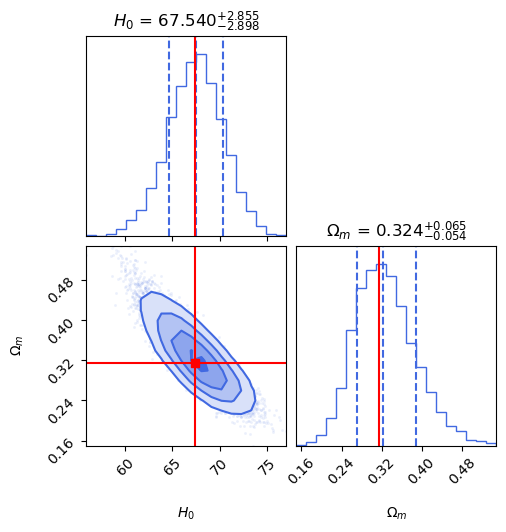

In [4]:
# LCDM using only CC data

analyzer = CosmoAnalyzer(data_CC)
sampler_l = analyzer.run_mcmc(model_type='LCDM', nsteps=3000)
analyzer.plot_results(sampler_l)

100%|██████████| 3000/3000 [00:02<00:00, 1230.08it/s]


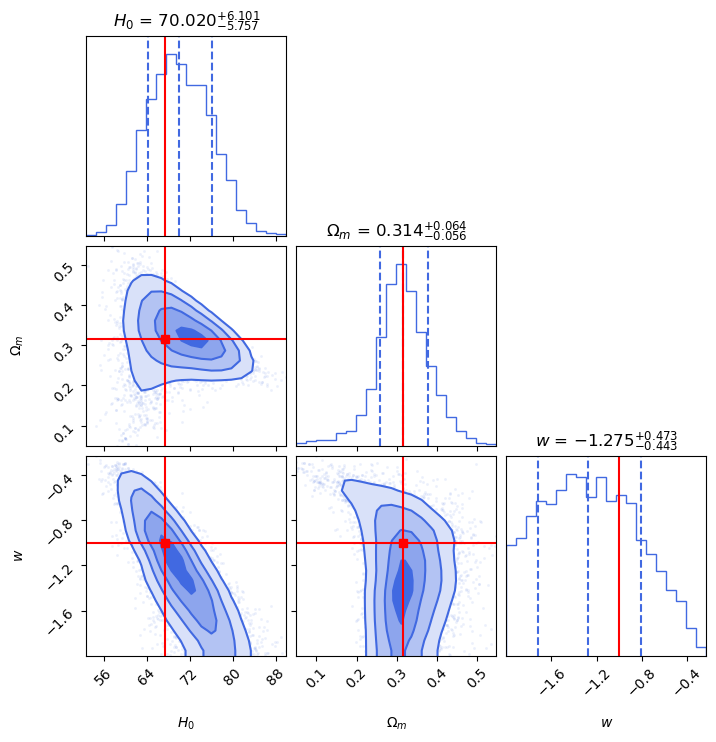

In [5]:
# wCDM using only CC data

analyzer = CosmoAnalyzer(data_CC)
sampler_w = analyzer.run_mcmc(model_type='wCDM', nsteps=3000)
analyzer.plot_results(sampler_w)

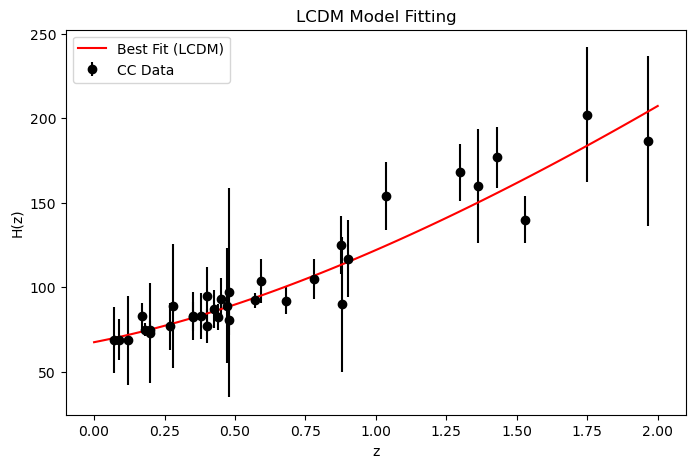

In [6]:
# LCDM Fitting with CC Data

analyzer.plot_hubble_fit_cc(sampler_l)

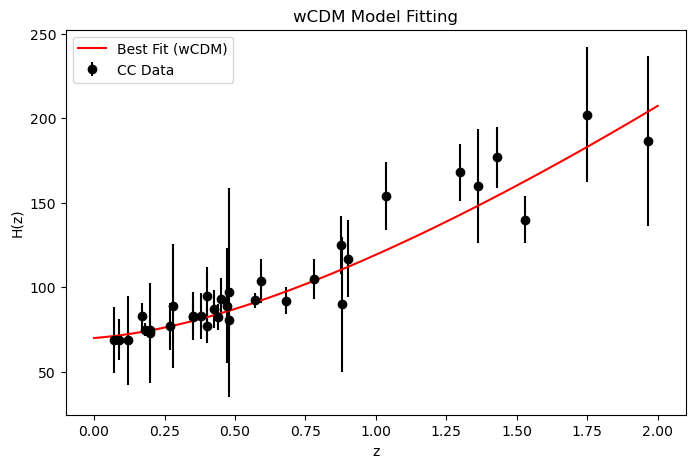

In [7]:
# wCDM Fitting with CC Data

analyzer.plot_hubble_fit_cc(sampler_w, model_type='wCDM')

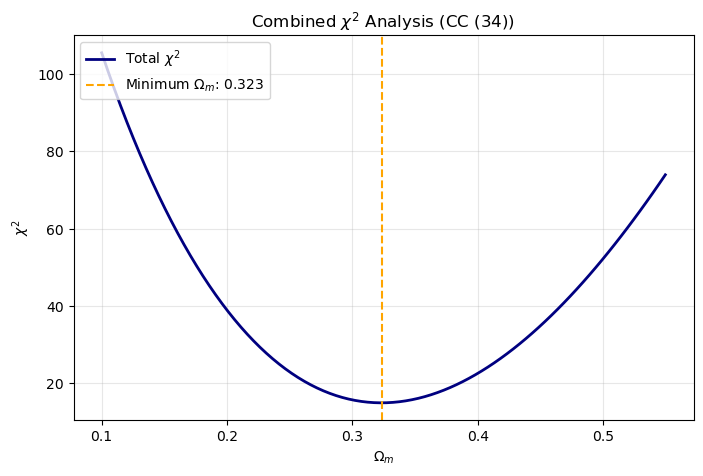

In [8]:
# LCDM Chi2 Analysis

analyzer.plot_chi2_analysis(sampler_l, model_type='LCDM')

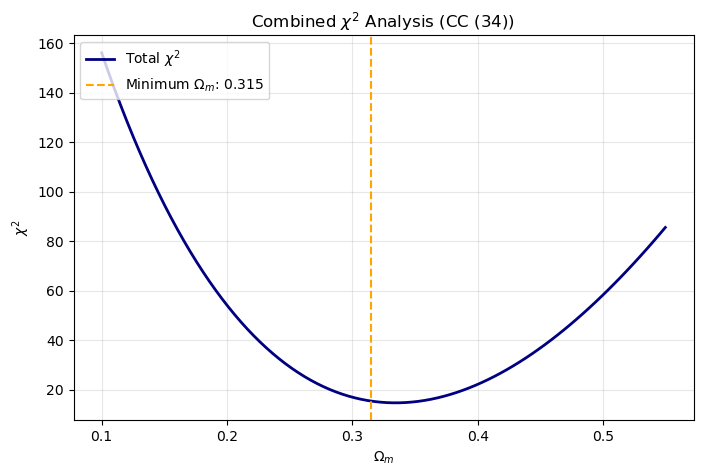

In [9]:
# wCDM Chi2 Analysis

analyzer.plot_chi2_analysis(sampler_w, model_type='wCDM')

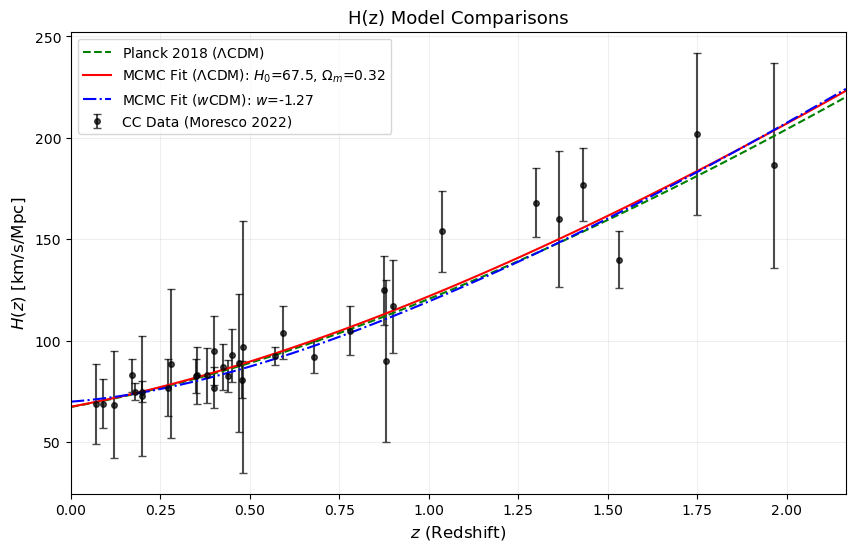

In [10]:
# H(z) Model Comparisons

analyzer.plot_model_comparison(sampler_l, sampler_w)

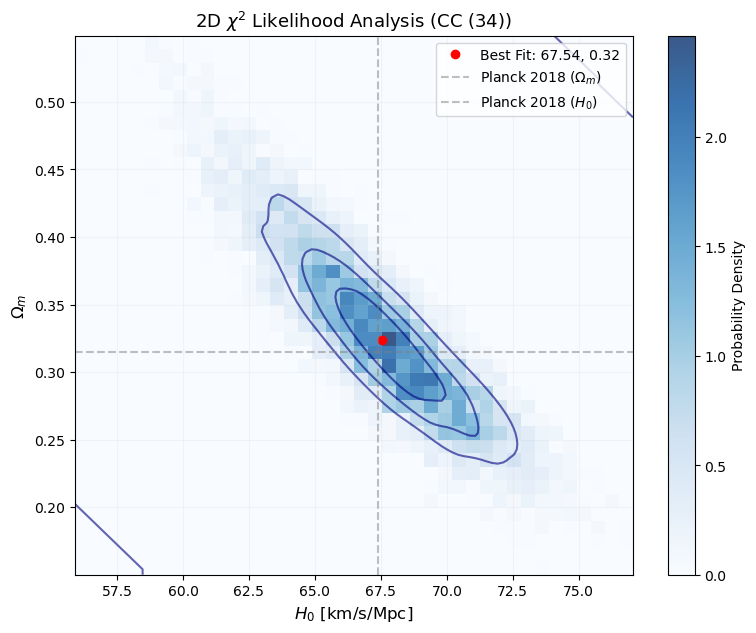

In [11]:
# LCDM 2D Chi2 Analysis

analyzer.plot_2d_chi2_analysis(sampler_l)

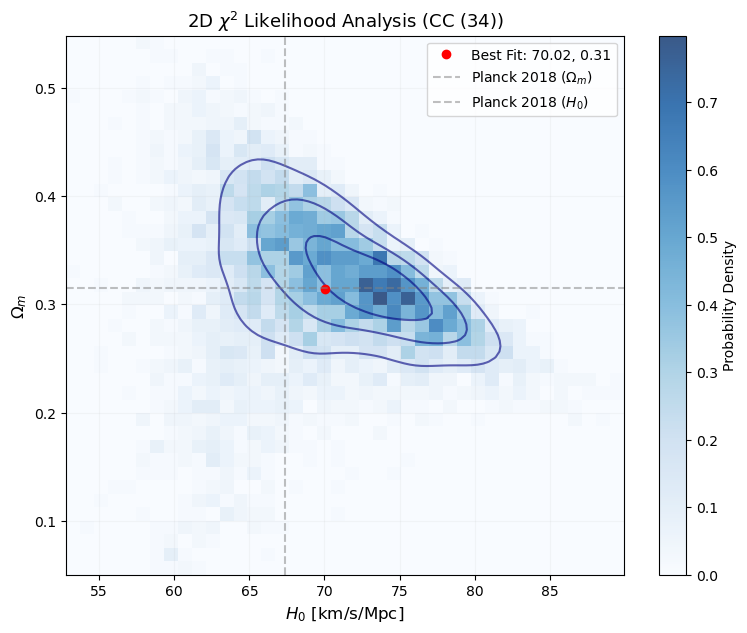

In [12]:
# wCDM 2D Chi2 Analysis

analyzer.plot_2d_chi2_analysis(sampler_w)

Calculating H0-Om surface for LCDM...


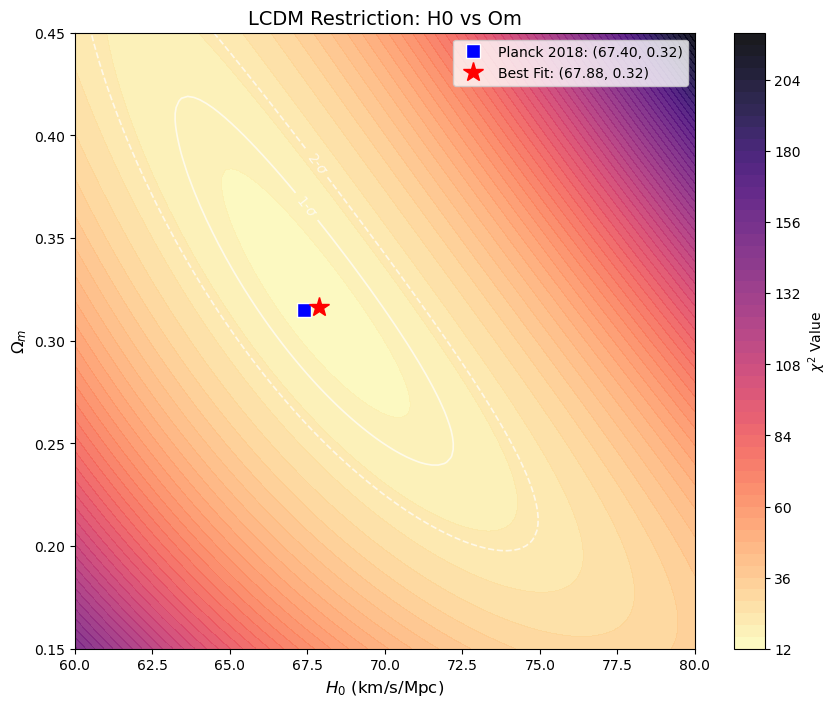

In [13]:
# LCDM Contour Analysis

analyzer.plot_grid_search_contour(model_type='LCDM', x_param='H0', y_param='Om')

Calculating Om-w surface for wCDM...


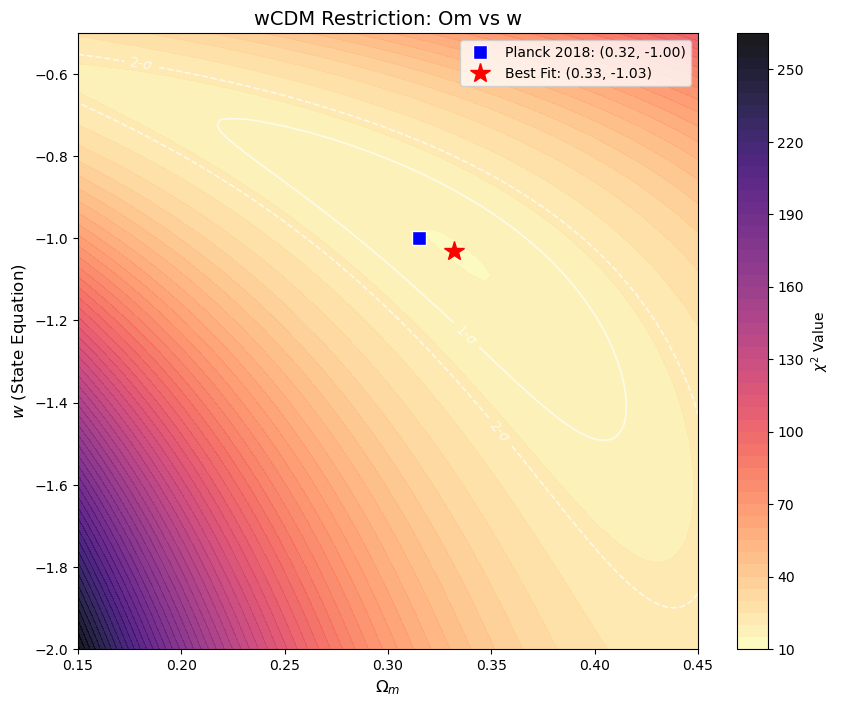

In [14]:
# wCDM O_m - w Contour Analysis

analyzer.plot_grid_search_contour(model_type='wCDM', x_param='Om', y_param='w', fixed_val=67.4)

Calculating H0-w surface for wCDM...


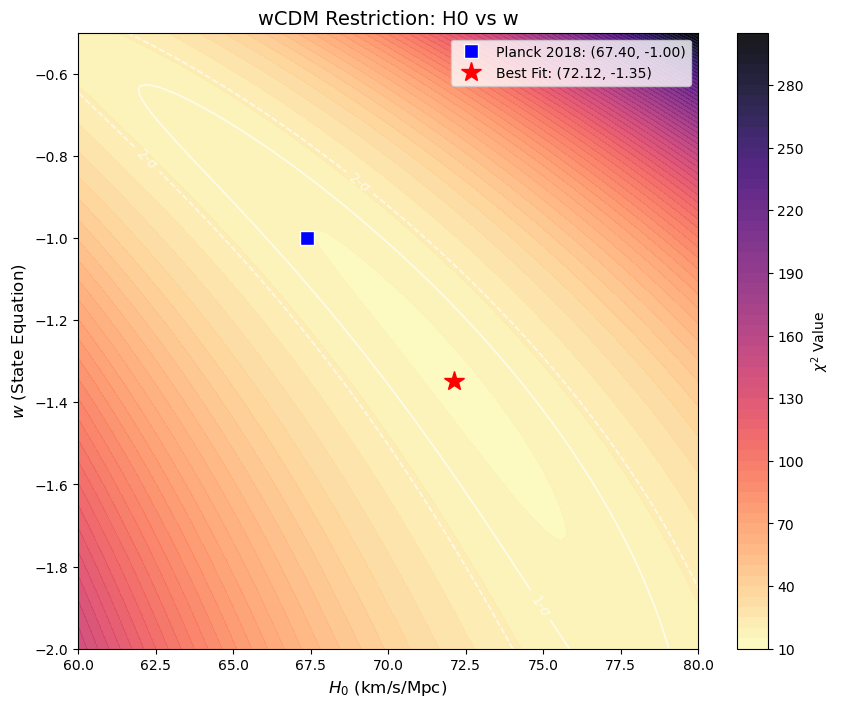

In [15]:
# wCDM H_0 - w Contour Analysis

analyzer.plot_grid_search_contour(model_type='wCDM', x_param='H0', y_param='w', fixed_val=0.3)

100%|██████████| 3000/3000 [00:08<00:00, 339.17it/s]


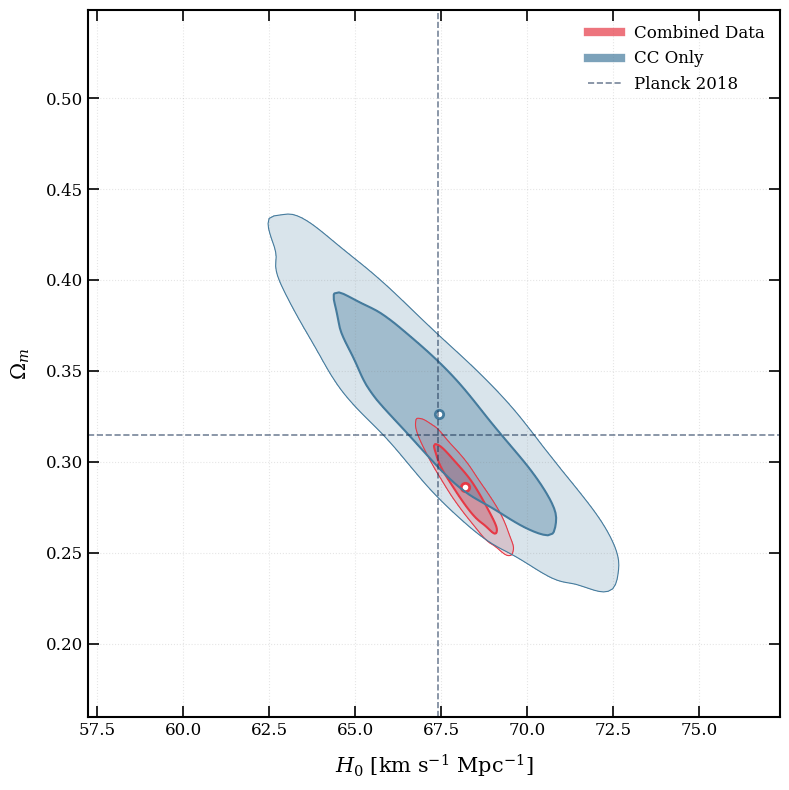

In [16]:
analyzer = CosmoAnalyzer(data_CC)
sampler_cc = analyzer.run_mcmc(model_type='LCDM', nsteps=3000)

analyzer_all = CosmoAnalyzer(data_CC, None, data_BAO)
sampler_all = analyzer_all.run_mcmc(model_type='LCDM', nsteps=3000)

analyzer.plot_degeneracy_breaking({'Combined Data': sampler_all, 'CC Only': sampler_cc})

100%|██████████| 3000/3000 [00:09<00:00, 308.21it/s]


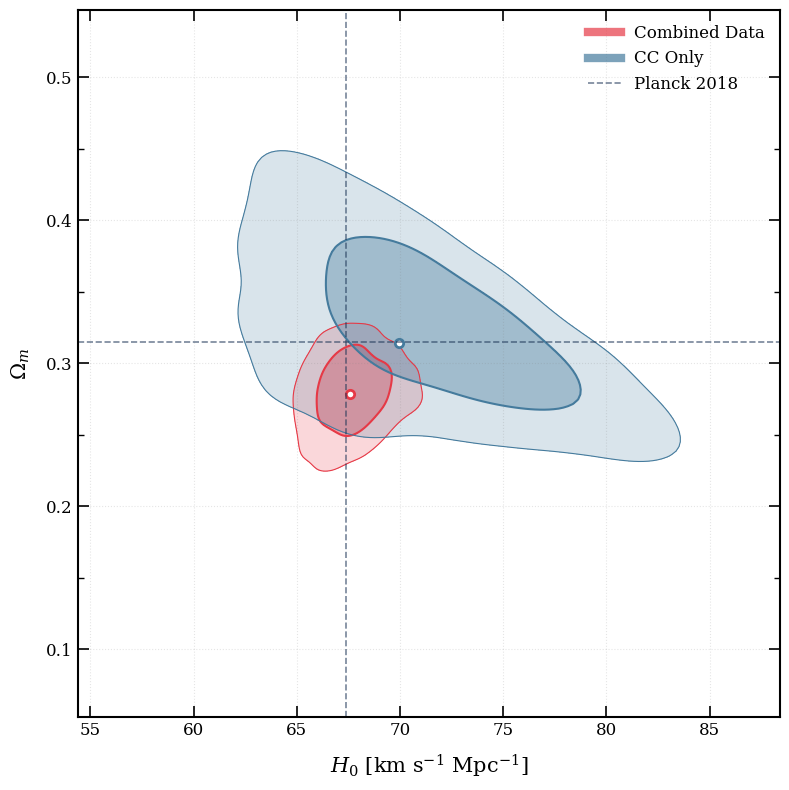

In [17]:
analyzer = CosmoAnalyzer(data_CC)
sampler_cc = analyzer.run_mcmc(model_type='wCDM', nsteps=3000)

analyzer_all = CosmoAnalyzer(data_CC, None, data_BAO)
sampler_all = analyzer_all.run_mcmc(model_type='wCDM', nsteps=3000)

analyzer.plot_degeneracy_breaking({'Combined Data': sampler_all, 'CC Only': sampler_cc})

100%|██████████| 3000/3000 [00:02<00:00, 1195.14it/s]


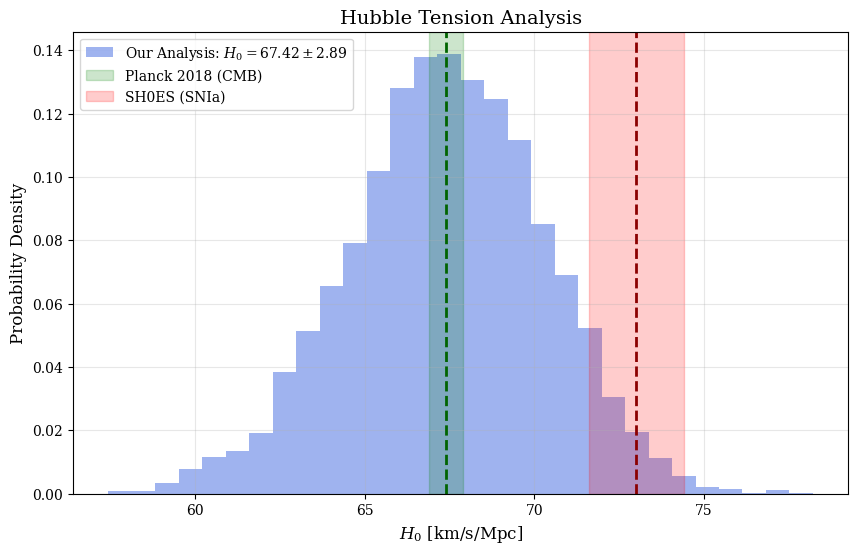

In [18]:
# CC vs Planck and SH0ES

analyzer = CosmoAnalyzer(data_CC)
sampler = analyzer.run_mcmc(model_type='LCDM', nsteps=3000)
analyzer.plot_hubble_tension(sampler)